# Filtering TM/TR CDF plot (0608)

注意，_tf/_filt，增加了nsamp参数前缀

Set `DATA_FOLDER`, then run all cells. This notebook only draws the original CDF data up to `QUANTILE_DROP=0.995`; it does not drop data and does not renormalize the CDF.


In [176]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
DATA_FOLDERS = [
    # Path('/astrum/home/hpchzy/code/data/20260608/camd9554n1/output_filt/20260608-184422/'),     # camd9554n1, 纯sub
    # Path('/astrum/home/hpchzy/code/data/20260608/camd9554n1/output_filt/20260608-192413/'),     # camd9554n1, 纯sub, 保守优化filt。 1.0会有大量负数！
    # Path('/astrum/home/hpchzy/code/data/20260608/camd9554n1/output_filt/20260608-193938/'),     # camd9554n1, 纯sub, 保守优化filt。看看0.5 0.75。tf还是有负数，就是实际比理论快！
    # Path('/astrum/home/hpchzy/code/data/20260608/camd9554n1/output_filt/20260608-203055/'),     # camd9554n1, 纯sub,ASM, 保守优化filt。看看0.5 0.75。
    # Path('/astrum/home/hpchzy/code/data/20260608/camd9554n1/output_filt/20260608-215031/'),     # camd9554n1, 纯sub,ASM, 原filt。看看0.5 0.75。

        # Path('/astrum/home/hpchzy/code/data/20260608/camd9554n1/output_filt/20260608-213911/'),     # camd9554n1, 纯sub,ASM, 保守优化filt。看看0.5 0.75。
    Path('/astrum/home/hpchzy/code/data/20260608/camd9554n1/output_filt/20260608-222153/'),     # camd9554n1, 纯sub,ASM, 保守优化filt。看看0.5 0.75。ntest=100,之前是10
]

QUANTILE_DROP = 0.995  # only draw CDF values from 0 to 0.995; no data deletion, no renormalization
SAVE_FIG = False
OUT_DIR = Path('/astrum/home/hpchzy/code/TacVar/stencil/plots_0604')

TIMER_COLORS = {
    'cgt': '#ff7f0e',
    'clock_gettime': '#ff7f0e',
    'wtime': '#2ca02c',
    'mpi_wtime': '#2ca02c',
    'papi': '#d62728',
    'papix6': '#9467bd',
    'likwid': '#8c564b',
    'tsc': '#1f77b4',
    'tsc_fence': '#4f8dd3',
    'tsc_native': '#17becf',
    'cntvct': '#00a6d6',
    'cntvcto': '#e377c2',
}

TIMER_LABELS = {
    'tsc': 'TSC',
    'tsc_fence': 'TSC_Fence',
    'tsc_native': 'TSC_Native',
    'cgt': 'clock_gettime',
    'clock_gettime': 'clock_gettime',
    'wtime': 'MPI_Wtime',
    'mpi_wtime': 'MPI_Wtime',
    'papi': 'PAPI',
    'papix6': 'PAPIx6',
    'likwid': 'LIKWID',
    'cntvct': 'CNTVCT',
    'cntvcto': 'CNTVCTO',
}

KERNEL_LABELS = {
    'jacobi2d5p': '2D 5-Point Jacobi Stencil',
}

HOST_LABELS = {
    'c920bn3': 'Kunpeng 920B',
    'camd9554n2': 'AMD EPYC 9554',
    'cgnr6760pn2': 'Intel Xeon 6760P',
}


In [178]:
def parse_filt_dir(path):
    m = re.match(r'(?P<kernel>.+)_(?P<timer>.+)_np(?P<np>\d+)_size(?P<size>\d+)_nsampRatio(?P<nsampRatio>[\d.]+)_nsamp(?P<nsamp>\d+)_filt$', path.name)
    if not m:
        return None
    d = m.groupdict()
    d['np'] = int(d['np'])
    d['size'] = int(d['size'])
    d['nsamp'] = int(d['nsamp'])
    d['nsampRatio'] = float(d['nsampRatio'])
    return d


def host_from_data_folder(data_folder):
    parts = Path(data_folder).parts
    if 'data' in parts:
        i = parts.index('data')
        if len(parts) > i + 2:
            return parts[i + 2]
    return Path(data_folder).name


def timer_label(timer):
    return TIMER_LABELS.get(timer, timer.upper().replace('_', '-'))


def timer_sort_key(timer):
    order = ['tsc', 'tsc_fence', 'tsc_native', 'cgt', 'clock_gettime', 'wtime', 'mpi_wtime', 'papi', 'papix6', 'likwid', 'cntvct', 'cntvcto']
    return (order.index(timer) if timer in order else len(order), timer)


def ecdf_xy(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    vals = np.sort(vals)
    if vals.size == 0:
        return vals, vals
    y = np.arange(1, vals.size + 1) / vals.size
    keep = y <= QUANTILE_DROP
    x = vals[keep]
    y = y[keep]
    if x.size:
        x = np.r_[x[0], x]
        y = np.r_[0.0, y]
    return x, y


def read_tm(tm_file):
    df = pd.read_csv(tm_file, header=None, names=['ns'])
    return df['ns'].to_numpy()


def read_tr(tr_hist_file):
    df = pd.read_csv(tr_hist_file, header=None, names=['ns', 'prob'])
    df['ns'] = pd.to_numeric(df['ns'], errors='coerce')
    df['prob'] = pd.to_numeric(df['prob'], errors='coerce')
    df = df[np.isfinite(df['ns']) & np.isfinite(df['prob'])].copy()
    df = df[df['prob'] > 0]
    df.sort_values('ns', inplace=True)
    df['cdf'] = df['prob'].cumsum()
    if len(df) and df['cdf'].iloc[-1] != 0:
        df['cdf'] = df['cdf'] / df['cdf'].iloc[-1]
    df = df[df['cdf'] <= QUANTILE_DROP]
    if len(df):
        first = df.iloc[[0]].copy()
        first['prob'] = 0.0
        first['cdf'] = 0.0
        df = pd.concat([first, df], ignore_index=True)
    return df


def collect_entries(data_folder):
    rows = []
    data_folder = Path(data_folder)
    host = host_from_data_folder(data_folder)
    for tr_hist_file in sorted(data_folder.glob('*/tr_hist.csv')):
        filt_dir = tr_hist_file.parent
        meta = parse_filt_dir(filt_dir)
        if meta is None:
            continue
        tm_file = filt_dir / 'met.csv'
        if not tm_file.exists():
            print(f'skip missing met.csv: {filt_dir}')
            continue
        rows.append({**meta, 'host': host, 'data_folder': data_folder, 'filt_dir': filt_dir, 'tm_file': tm_file, 'tr_hist_file': tr_hist_file})
    return pd.DataFrame(rows)

entries = pd.concat([collect_entries(p) for p in DATA_FOLDERS], ignore_index=True)
print(f'entries: {len(entries)}')
entries.sort_values(['host', 'kernel', 'np', 'size', 'timer']).head(20)


entries: 18


,kernel,timer,np,size,nsampRatio,nsamp,host,data_folder,filt_dir,tm_file,tr_hist_file
0,jacobi2d5p,cgt,64,512,0.50,1395,camd9554n1,/astrum/home/hpchzy/code/data/20260608/camd955...,/astrum/home/hpchzy/code/data/20260608/camd955...,/astrum/home/hpchzy/code/data/20260608/camd955...,/astrum/home/hpchzy/code/data/20260608/camd955...
1,jacobi2d5p,cgt,64,512,0.75,1646,camd9554n1,/astrum/home/hpchzy/code/data/20260608/camd955...,/astrum/home/hpchzy/code/data/20260608/camd955...,/astrum/home/hpchzy/code/data/20260608/camd955...,/astrum/home/hpchzy/code/data/20260608/camd955...
2,jacobi2d5p,cgt,64,512,1.00,146757,camd9554n1,/astrum/home/hpchzy/code/data/20260608/camd955...,/astrum/home/hpchzy/code/data/20260608/camd955...,/astrum/home/hpchzy/code/data/20260608/camd955...,/astrum/home/hpchzy/code/data/20260608/camd955...
3,jacobi2d5p,papi,64,512,0.50,3289,camd9554n1,/astrum/home/hpchzy/code/data/20260608/camd955...,/astrum/home/hpchzy/code/data/20260608/camd955...,/astrum/home/hpchzy/code/data/20260608/camd955...,/astrum/home/hpchzy/code/data/20260608/camd955...
4,jacobi2d5p,papi,64,512,0.75,3447,camd9554n1,/astrum/home/hpchzy/code/data/20260608/camd955...,/astrum/home/hpchzy/code/data/20260608/camd955...,/astrum/home/hpchzy/code/data/20260608/camd955...,/astrum/home/hpchzy/code/data/20260608/camd955...
5,jacobi2d5p,papi,64,512,1.00,168485,camd9554n1,/astrum/home/hpchzy/code/data/20260608/camd955...,/astrum/home/hpchzy/code/data/20260608/camd955...,/astrum/home/hpchzy/code/data/20260608/camd955...,/astrum/home/hpchzy/code/data/20260608/camd955...
6,jacobi2d5p,papix6,64,512,0.50,3351,camd9554n1,/astrum/home/hpchzy/code/data/20260608/camd955...,/astrum/home/hpchzy/code/data/20260608/camd955...,/astrum/home/hpchzy/code/data/20260608/camd955...,/astrum/home/hpchzy/code/data/20260608/camd955...
7,jacobi2d5p,papix6,64,512,0.75,3537,camd9554n1,/astrum/home/hpchzy/code/data/20260608/camd955...,/astrum/home/hpchzy/code/data/20260608/camd955...,/astrum/home/hpchzy/code/data/20260608/camd955...,/astrum/home/hpchzy/code/data/20260608/camd955...
8,jacobi2d5p,papix6,64,512,1.00,3013271,camd9554n1,/astrum/home/hpchzy/code/data/20260608/camd955...,/astrum/home/hpchzy/code/data/20260608/camd955...,/astrum/home/hpchzy/code/data/20260608/camd955...,/astrum/home/hpchzy/code/data/20260608/camd955...
12,jacobi2d5p,tsc,64,512,0.50,1271,camd9554n1,/astrum/home/hpchzy/code/data/20260608/camd955...,/astrum/home/hpchzy/code/data/20260608/camd955...,/astrum/home/hpchzy/code/data/20260608/camd955...,/astrum/home/hpchzy/code/data/20260608/camd955...


# ER/EP/Wasserstein

In [179]:
from scipy.stats import wasserstein_distance


def read_float_file(path):
    try:
        text = Path(path).read_text().strip()
        return float(text) if text else np.nan
    except FileNotFoundError:
        print(f'warning: missing {path}')
        return np.nan
    except ValueError:
        print(f'warning: invalid float in {path}')
        return np.nan


def clean_hist_for_wd(hist_file, ns_col='ns', pr_col='pr'):
    df = pd.read_csv(hist_file, header=None, names=[ns_col, pr_col])
    df[ns_col] = pd.to_numeric(df[ns_col], errors='coerce')
    df[pr_col] = pd.to_numeric(df[pr_col], errors='coerce')
    df = df[np.isfinite(df[ns_col]) & np.isfinite(df[pr_col])].copy()
    df = df[df[pr_col] > 0]
    if df.empty or df[pr_col].sum() <= 0:
        return None
    return df


def wd_to_min(hist_file):
    df = clean_hist_for_wd(hist_file)
    if df is None:
        return np.nan
    ns = df['ns'].to_numpy(dtype=float)
    pr = df['pr'].to_numpy(dtype=float)
    return wasserstein_distance(ns, np.array([ns.min()]), pr, np.array([1.0]))


summary_rows = []
for idx, row in entries.iterrows():
    filt_folder = Path(row['filt_dir'])
    ep = read_float_file(filt_folder / 'ep.out')
    er = read_float_file(filt_folder / 'er.out')
    wd = read_float_file(filt_folder / 'wd.out')
    tm_wd = wd_to_min(filt_folder / 'tm_hist.csv')
    tr_wd = wd_to_min(filt_folder / 'tr_hist.csv')
    if not np.isfinite(tm_wd) or not np.isfinite(tr_wd):
        print(f"warning: invalid histogram for Wasserstein: {filt_folder.name} tm_wd={tm_wd} tr_wd={tr_wd}")
    summary_rows.append({**row.to_dict(), 'ep': ep, 'er': er, 'wd': wd, 'tm_wd': tm_wd, 'tr_wd': tr_wd})

df = pd.DataFrame(summary_rows).reset_index(drop=True)
df.sort_values(['host', 'kernel', 'np', 'size', 'timer'], inplace=True)
df[['host', 'kernel', 'timer', 'np', 'size', 'ep', 'er', 'wd', 'tm_wd', 'tr_wd']].head(20)


,host,kernel,timer,np,size,ep,er,wd,tm_wd,tr_wd
0,camd9554n1,jacobi2d5p,cgt,64,512,0.000000,0.029917,14.631156,79.223774,68.660889
1,camd9554n1,jacobi2d5p,cgt,64,512,0.192807,0.082838,40.512563,79.223774,104.150176
2,camd9554n1,jacobi2d5p,cgt,64,512,0.129256,0.393264,192.327638,79.223774,108.170317
3,camd9554n1,jacobi2d5p,papi,64,512,0.000443,0.063610,68.790955,89.958852,89.958990
4,camd9554n1,jacobi2d5p,papi,64,512,0.000443,0.083140,89.912563,89.958852,89.958990
5,camd9554n1,jacobi2d5p,papi,64,512,0.000443,0.225162,243.502513,89.958852,89.958990
6,camd9554n1,jacobi2d5p,papix6,64,512,0.000069,0.068770,75.791960,100.840189,100.840139
7,camd9554n1,jacobi2d5p,papix6,64,512,0.000069,0.078194,86.178894,100.840189,100.840139
8,camd9554n1,jacobi2d5p,papix6,64,512,0.000069,3.165742,3489.013065,100.840189,100.840139
12,camd9554n1,jacobi2d5p,tsc,64,512,0.000000,0.039788,17.788945,47.862872,31.059202


In [180]:
df["timer_label"] = df["timer"].map(TIMER_LABELS).fillna(df["timer"])
df["kernel_label"] = df["kernel"].map(KERNEL_LABELS).fillna(df["kernel"])


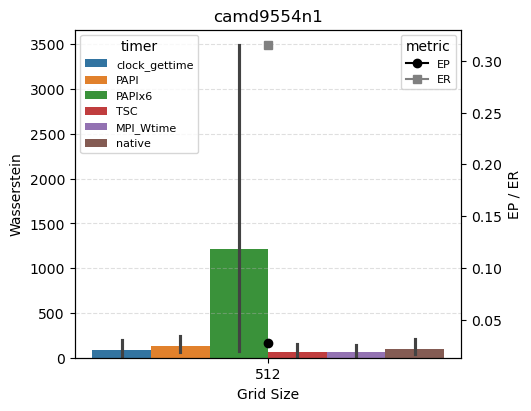

In [181]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

metric_bar = 'wd'
line_metrics = ['ep', 'er']

plot_df = df.copy()
plot_df['timer_label'] = plot_df['timer'].map(TIMER_LABELS).fillna(plot_df['timer'])
plot_df['size_str'] = plot_df['size'].astype(str)
size_order = [str(x) for x in sorted(plot_df['size'].unique())]
plot_df['size_str'] = pd.Categorical(plot_df['size_str'], categories=size_order, ordered=True)

hosts = [host_from_data_folder(p) for p in DATA_FOLDERS]
fig, axes = plt.subplots(1, len(hosts), figsize=(5.2 * len(hosts), 4), sharey=True, constrained_layout=True)
if len(hosts) == 1:
    axes = [axes]

right_axes = []
for ax1, host in zip(axes, hosts):
    host_df = plot_df[plot_df['host'] == host]
    sns.barplot(data=host_df, x='size_str', y=metric_bar, hue='timer_label', ax=ax1)
    HOSTNAME = host_df['host'].iloc[0]
    # ax1.set_title(f"{KERNEL_LABELS.get(plot_df['kernel'].iloc[0], plot_df['kernel'].iloc[0])} on {HOST_LABELS.get(HOSTNAME, HOSTNAME)}")
    ax1.set_title(f"{HOST_LABELS.get(HOSTNAME, HOSTNAME)}")
    ax1.set_xlabel('Grid Size')
    ax1.set_ylabel('Wasserstein' if ax1 is axes[0] else '')
    ax1.grid(axis='y', linestyle='--', alpha=0.4)

    ax2 = ax1.twinx()
    right_axes.append(ax2)
    line_df = host_df.groupby(['size_str'], observed=True)[line_metrics].mean().reset_index()
    x_pos = range(len(line_df))
    ax2.plot(x_pos, line_df['ep'], marker='o', label='EP', color='black')
    ax2.plot(x_pos, line_df['er'], marker='s', label='ER', color='gray')
    ax2.set_ylabel('EP / ER')
    ax2.set_xticks(list(x_pos))
    ax2.set_xticklabels(line_df['size_str'])

    
    ax1.legend(title='timer', fontsize=8, loc='upper left')
    ax2.legend(title='metric', fontsize=8, loc='upper right')

left_lims = [ax.get_ylim() for ax in axes]
right_lims = [ax.get_ylim() for ax in right_axes]
left_ylim = (min(lo for lo, hi in left_lims), max(hi for lo, hi in left_lims))
right_ylim = (min(lo for lo, hi in right_lims), max(hi for lo, hi in right_lims))
for ax in axes:
    ax.set_ylim(left_ylim)
for ax in right_axes:
    ax.set_ylim(right_ylim)

plt.show()


# Filt Plot

In [182]:
entries['nsamp'].unique()

array([   1395,    1646,  146757,    3289,    3447,  168485,    3351,
          3537, 3013271,    1333,    1550,  182366,    1271,    1426,
        144956,    1367,    1584,  131728])

            kernel   timer  np  size  nsampRatio  nsamp        host  \
0       jacobi2d5p     cgt  64   512        0.50   1395  camd9554n1   
1       jacobi2d5p     cgt  64   512        0.75   1646  camd9554n1   
3       jacobi2d5p    papi  64   512        0.50   3289  camd9554n1   
4       jacobi2d5p    papi  64   512        0.75   3447  camd9554n1   
6       jacobi2d5p  papix6  64   512        0.50   3351  camd9554n1   
7       jacobi2d5p  papix6  64   512        0.75   3537  camd9554n1   
9   jacobi2d5p_tsc  native  64   512        0.50   1333  camd9554n1   
10  jacobi2d5p_tsc  native  64   512        0.75   1550  camd9554n1   
12      jacobi2d5p     tsc  64   512        0.50   1271  camd9554n1   
13      jacobi2d5p     tsc  64   512        0.75   1426  camd9554n1   
15      jacobi2d5p   wtime  64   512        0.50   1367  camd9554n1   
16      jacobi2d5p   wtime  64   512        0.75   1584  camd9554n1   

                                          data_folder  \
0   /astrum/home/hp

/astrum/home/hpchzy/miniconda3/envs/xfold-scripts/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


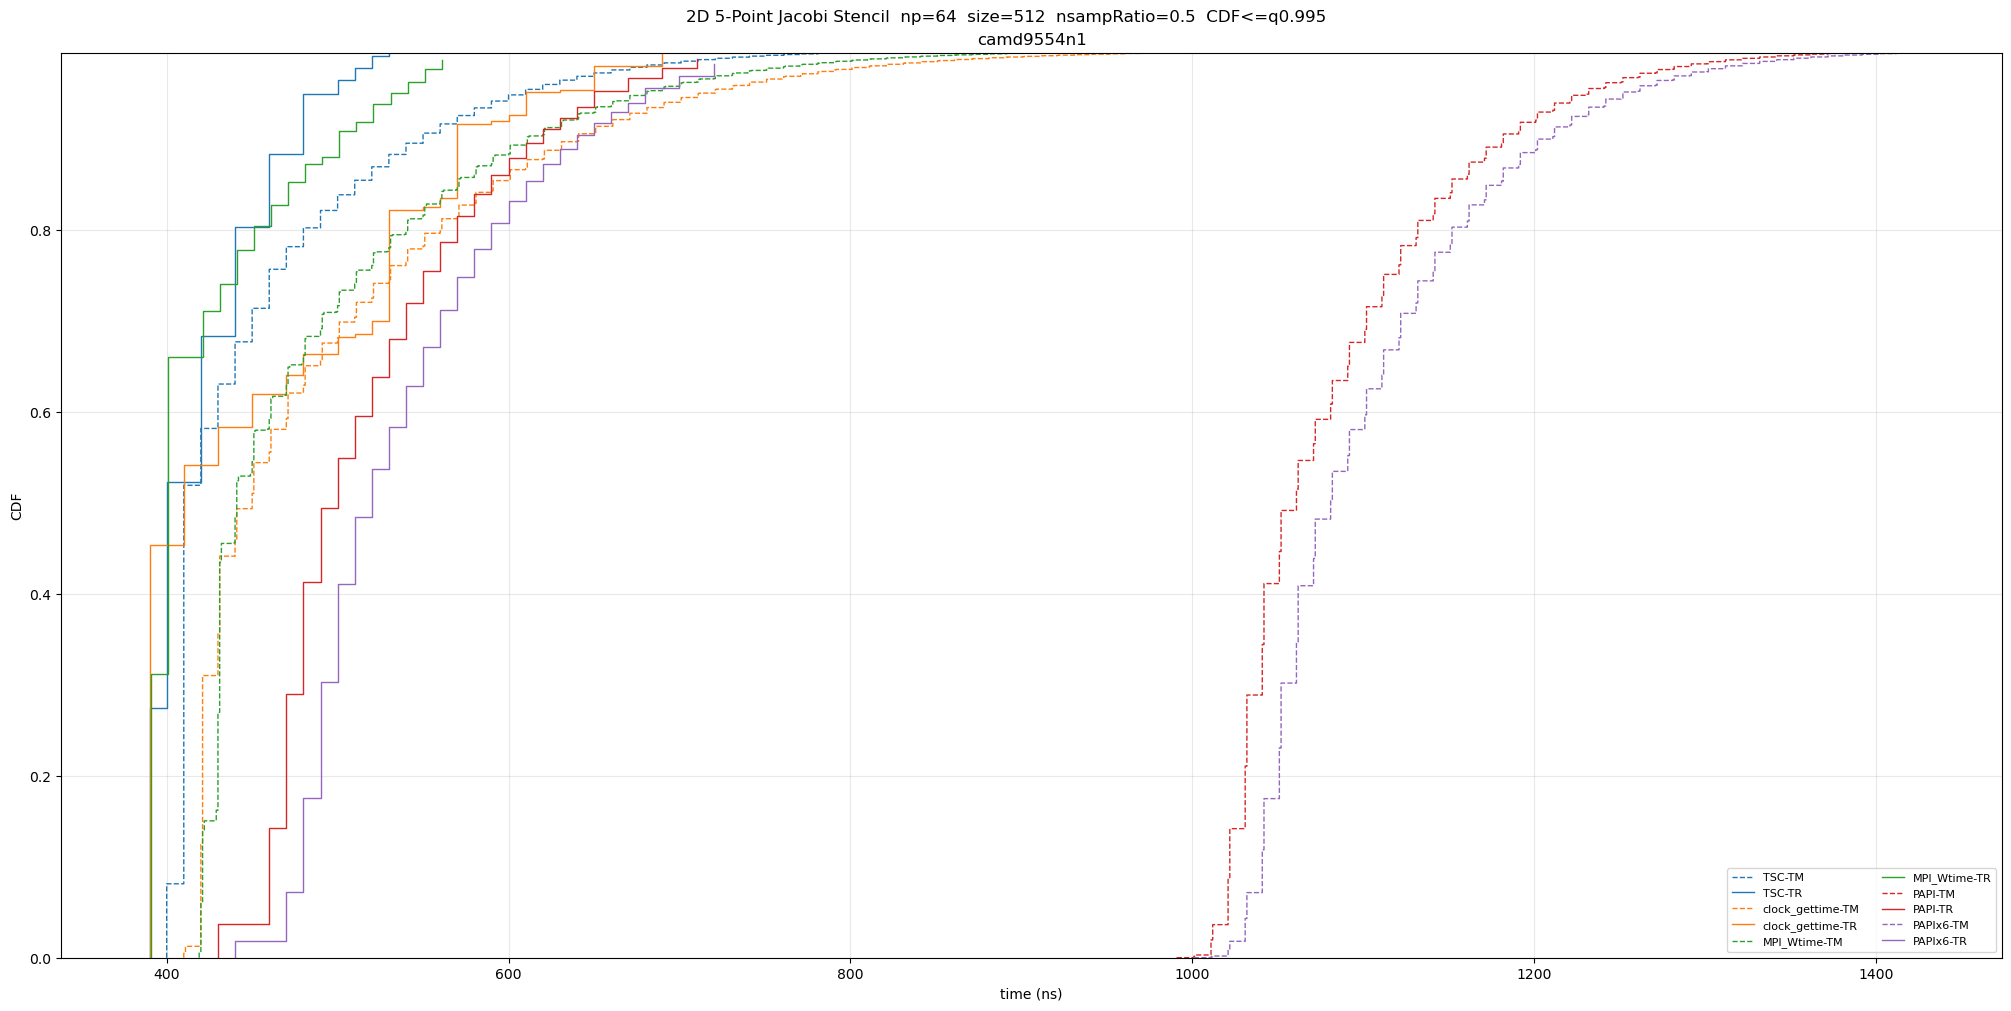

/astrum/home/hpchzy/miniconda3/envs/xfold-scripts/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


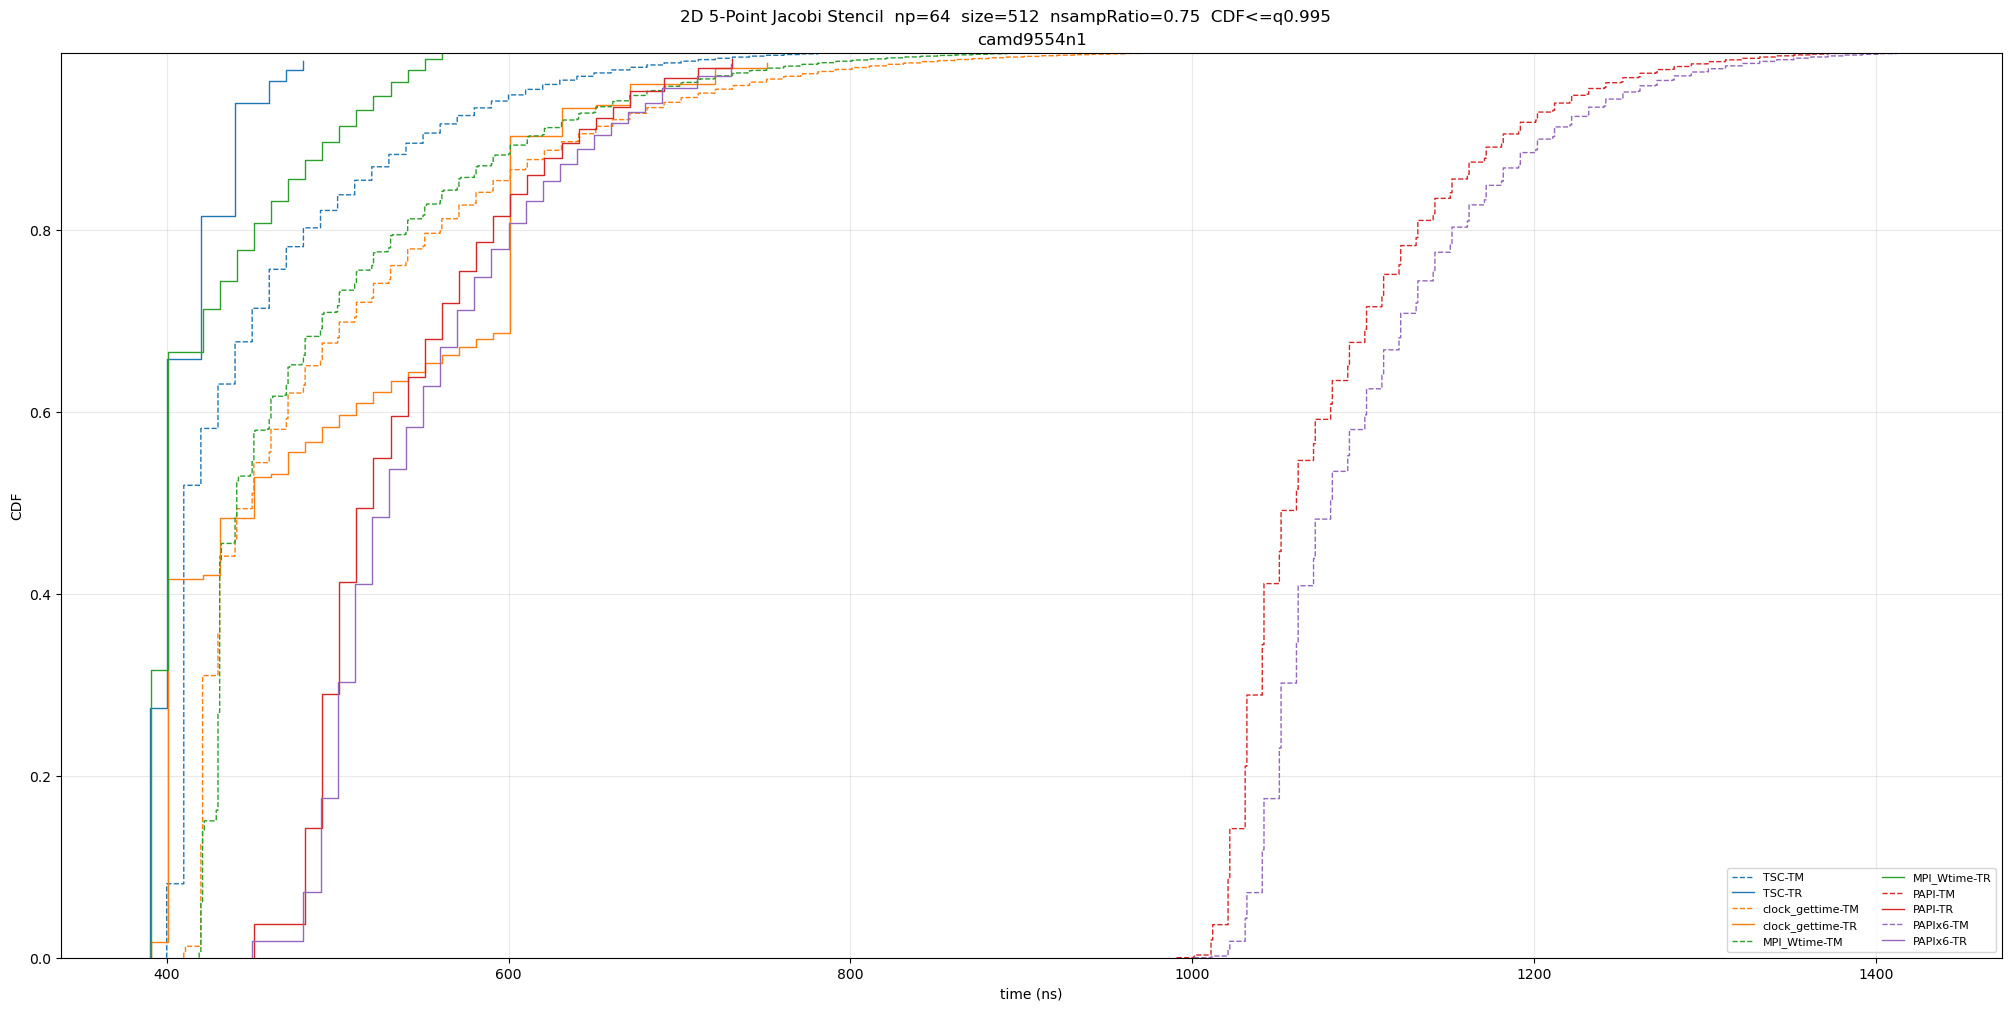

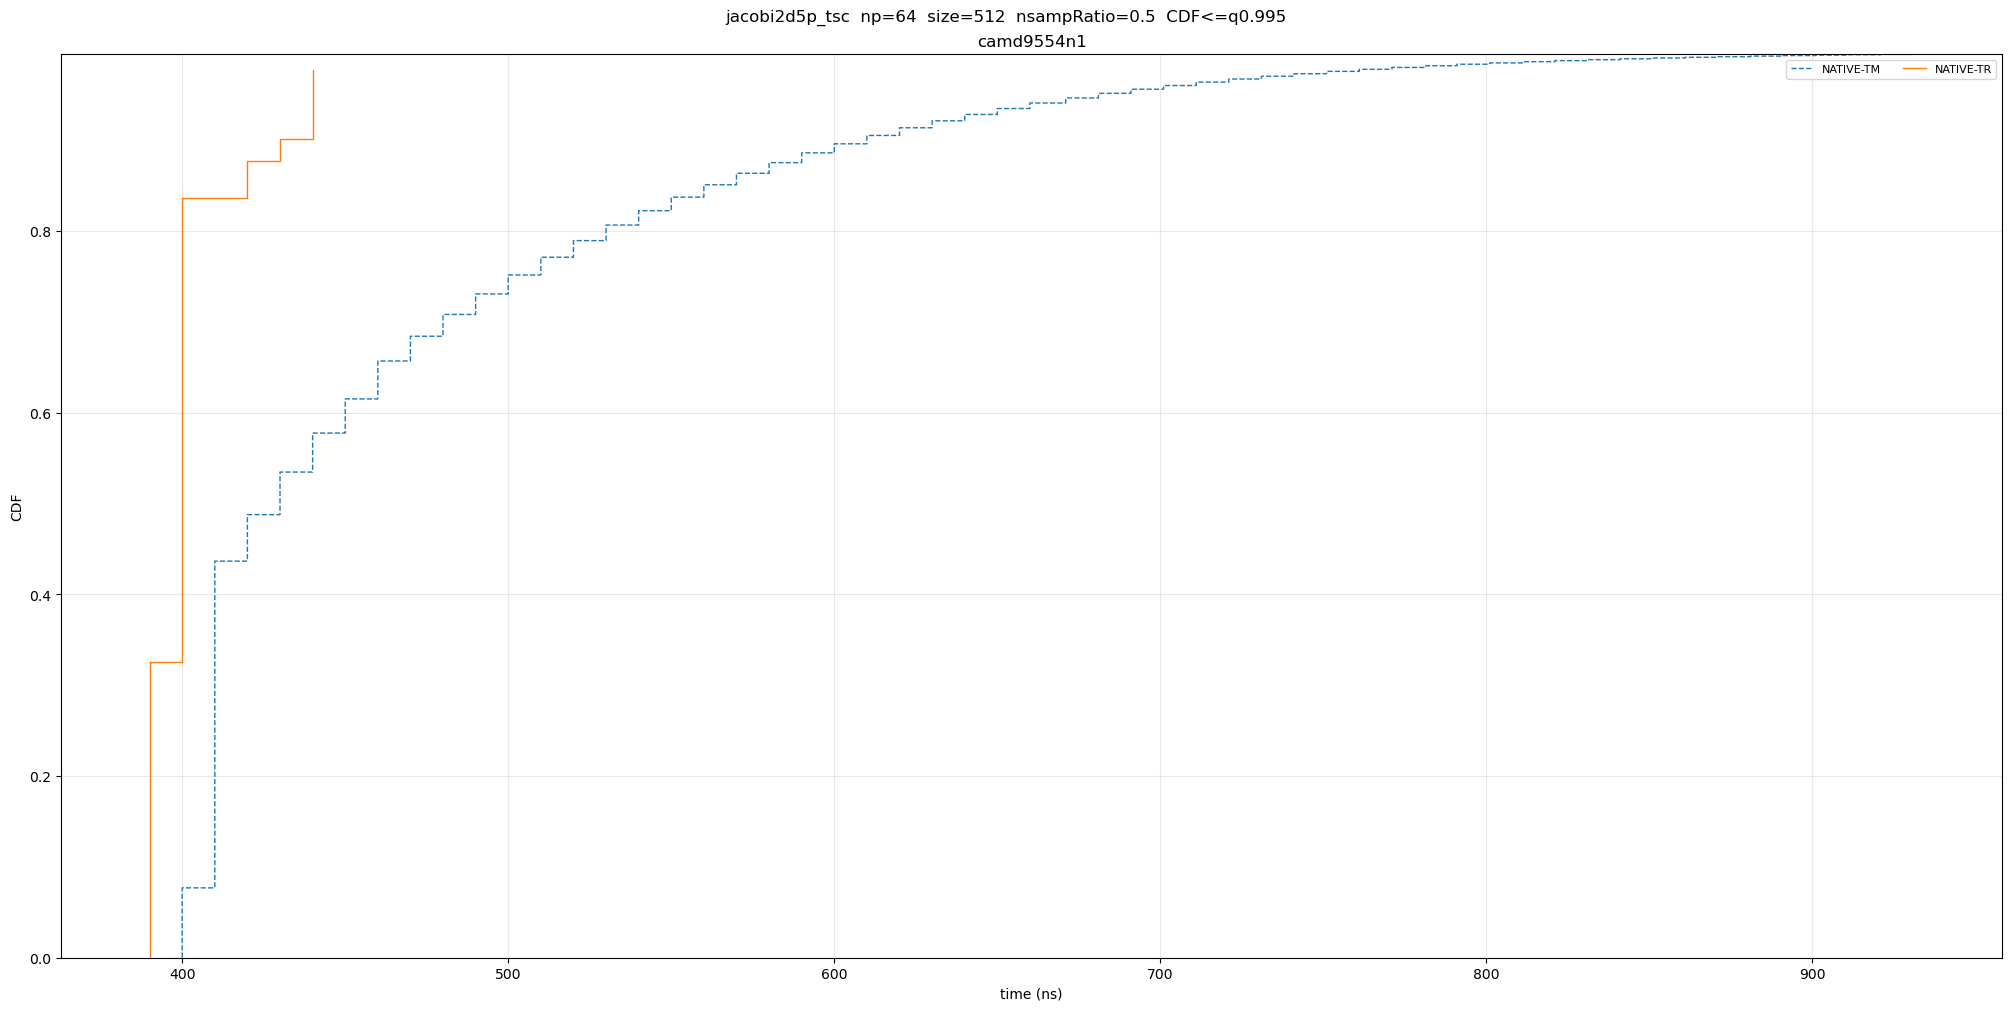

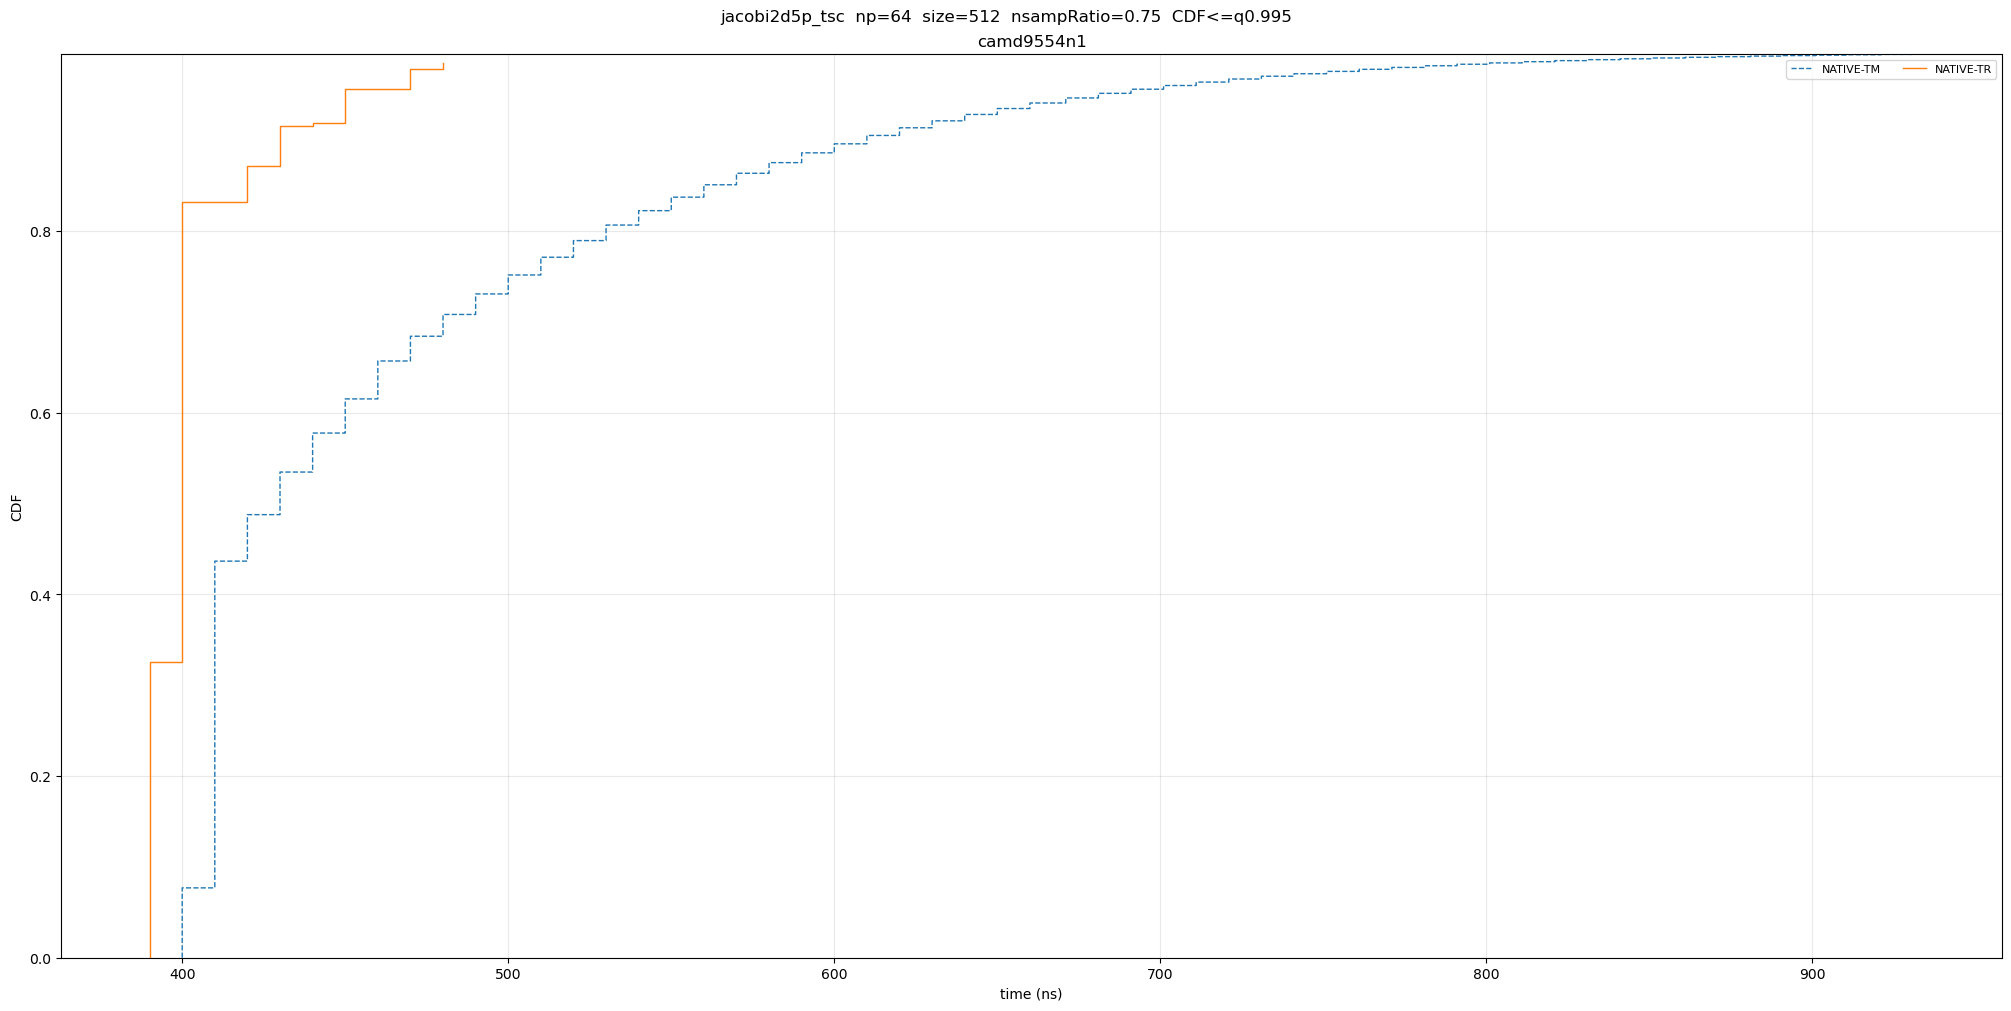

In [183]:
# entries_plot = entries[(entries['size'] == 2048) & (entries['timer'] != 'likwid')]
entries_plot = entries[(entries['timer'] != 'likwid') & (entries['nsampRatio'].isin([0.5, 0.75]))]

print(entries_plot)


if entries_plot.empty:
    raise RuntimeError('No *_filt/tr_hist.csv entries found for size=2048 under DATA_FOLDERS')

if SAVE_FIG:
    OUT_DIR.mkdir(parents=True, exist_ok=True)

hosts = [host_from_data_folder(p) for p in DATA_FOLDERS]

for (kernel, np_val, size, nsamp_ratio), group_all in entries_plot.groupby(['kernel', 'np', 'size', 'nsampRatio'], sort=True):
    fig, axes = plt.subplots(1, len(hosts), figsize=(20.0 * len(hosts), 10), sharey=True, constrained_layout=True)
    if len(hosts) == 1:
        axes = [axes]

    for ax, host in zip(axes, hosts):
        group = group_all[group_all['host'] == host].sort_values('timer', key=lambda s: s.map(timer_sort_key))

        for _, row in group.iterrows():
            timer = row['timer']
            color = TIMER_COLORS.get(timer)
            label = timer_label(timer)

            tm_x, tm_y = ecdf_xy(read_tm(row['tm_file']))
            tr_df = read_tr(row['tr_hist_file'])

            ax.step(tm_x, tm_y, label=f'{label}-TM', color=color, linestyle='--', linewidth=1.0, where='post')
            ax.step(tr_df['ns'], tr_df['cdf'], label=f'{label}-TR', color=color, linestyle='-', linewidth=1.0, where='post')

        ax.set_title(f"{HOST_LABELS.get(host, host)}")
        ax.set_xlabel('time (ns)')
        ax.set_ylim(0, QUANTILE_DROP)
        ax.grid(True, alpha=0.28)
        ax.legend(ncol=2, fontsize=8)

    xlims = [ax.get_xlim() for ax in axes]
    xlim = (min(lo for lo, hi in xlims), max(hi for lo, hi in xlims))
    for ax in axes:
        ax.set_xlim(xlim)
        ax.set_ylim(0, QUANTILE_DROP)

    axes[0].set_ylabel('CDF')
    fig.suptitle(f'{KERNEL_LABELS.get(kernel, kernel)}  np={np_val}  size={size}  nsampRatio={nsamp_ratio}  CDF<=q{QUANTILE_DROP}')

    if SAVE_FIG:
        out = OUT_DIR / f'{kernel}_np{np_val}_size{size}_ratio{nsamp_ratio}_tm_tr_by_host.png'
        fig.savefig(out, dpi=220, bbox_inches='tight')
        print(out)

    plt.show()